In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Results Import

In [2]:
ds1 = xr.open_dataset('Results/CANI_EANI_CESM21.nc')

In [3]:
model_EANI = ds1['EANI']
model_CANI = ds1['CANI']

In [4]:
ds2 = xr.open_dataset('Results/Reanalysis_vars.nc')

In [5]:
re_EANI = ds2['EANI_var']
re_CANI = ds2['CANI_var']

In [6]:
re_CvE = ds2['CvE']

# Calculate var and ensemble means of vars

In [7]:
# select only the summer of the index
mEANI_JJA = model_EANI.where(model_EANI.time.dt.month.isin([6, 7, 8]), drop=True)
mCANI_JJA = model_CANI.where(model_CANI.time.dt.month.isin([6, 7, 8]), drop=True)

mEANI_JJA_mean = mEANI_JJA.groupby('time.year').mean()
mCANI_JJA_mean = mCANI_JJA.groupby('time.year').mean()

var_roll = 21
mEANI_var = mEANI_JJA_mean.rolling(year=var_roll, center=True).var()
mCANI_var = mCANI_JJA_mean.rolling(year=var_roll, center=True).var()

mCvE_r = mCANI_var / mEANI_var

In [8]:
ens_CvE = mCvE_r.mean(dim='member')
ens_EANIvar = mEANI_var.mean(dim='member')
ens_CANIvar = mCANI_var.mean(dim='member')

# Plots

## EANI

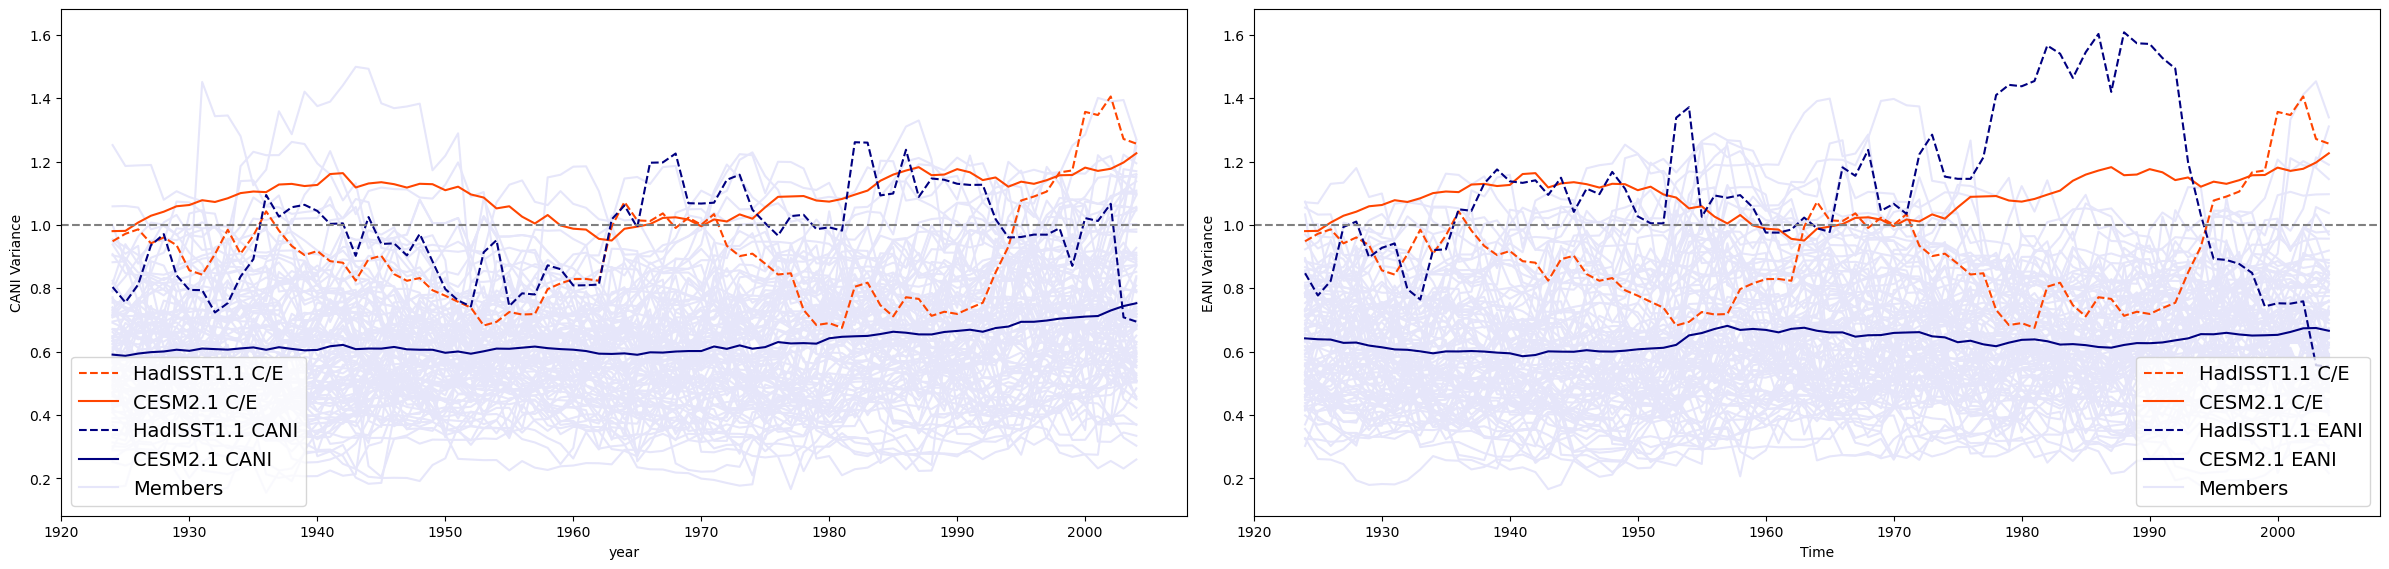

In [11]:
fig = plt.figure(figsize=(24, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

mCANI_var.plot(ax=ax1, hue='member', x='year', alpha=1, color='lavender', add_legend=False)
re_CvE.plot(ax=ax1, label='HadISST1.1 C/E', linestyle='--', color='orangered')
ens_CvE.plot(ax=ax1, label='CESM2.1 C/E', color='orangered')
re_CANI.plot(ax=ax1, label='HadISST1.1 CANI', linestyle='--', color='navy')
ens_CANIvar.plot(ax=ax1, label='CESM2.1 CANI', color='navy')
mCANI_var.sel(member=0).plot(ax=ax1, hue='member', x='year', alpha=1, color='lavender', label='Members', zorder=0)

mEANI_var.plot(ax=ax2, hue='member', x='year', alpha=1, color='lavender', add_legend=False)
re_CvE.plot(ax=ax2, label='HadISST1.1 C/E', linestyle='--', color='orangered')
ens_CvE.plot(ax=ax2, label='CESM2.1 C/E', color='orangered')
re_EANI.plot(ax=ax2, label='HadISST1.1 EANI', linestyle='--', color='navy')
ens_EANIvar.plot(ax=ax2, label='CESM2.1 EANI', color='navy')
mEANI_var.sel(member=0).plot(ax=ax2, hue='member', x='year', alpha=1, color='lavender', label='Members', zorder=0)



ax1.axhline(1, color='grey', ls='--')
ax2.axhline(1, color='grey', ls='--')

plt.tight_layout()
ax1.set_title('')
ax2.set_title('')
ax1.set_ylabel('CANI Variance')
ax2.set_ylabel('EANI Variance')
plt.xlabel('Time')
ax1.legend(loc='lower left', fontsize=14)
ax2.legend(loc='lower right', fontsize=14)
plt.savefig('Variance comparison', dpi=300)

##